# Fund Performance Analytics

## Capstone Project I - Mutual Fund Analytics

### Objective

Analyze the performance and risk characteristics of 40 mutual fund schemes using historical NAV data.

The analysis includes:

- Daily Returns
- 1-Year, 3-Year and 5-Year CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha and Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison
- Tracking Error

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 1. Load NAV History Data

In [2]:
nav_df = pd.read_csv("../data/processed/02_nav_history.csv")

nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav_df.columns.tolist()

['amfi_code', 'date', 'nav']

In [4]:
print("Shape:", nav_df.shape)

print("\nColumns:")
print(nav_df.columns.tolist())

print("\nData Types:")
print(nav_df.dtypes)

print("\nMissing Values:")
print(nav_df.isnull().sum())

print("\nDuplicate Rows:")
print(nav_df.duplicated().sum())

Shape: (46000, 3)

Columns:
['amfi_code', 'date', 'nav']

Data Types:
amfi_code      int64
date             str
nav          float64
dtype: object

Missing Values:
amfi_code    0
date         0
nav          0
dtype: int64

Duplicate Rows:
0


In [5]:
nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


## 2. Data Cleaning and Preparation

In [6]:
nav_df["date"] = pd.to_datetime(nav_df["date"], errors="coerce")
nav_df["nav"] = pd.to_numeric(nav_df["nav"], errors="coerce")

In [9]:
# Clean NAV data

nav_df["date"] = pd.to_datetime(nav_df["date"], errors="coerce")
nav_df["nav"] = pd.to_numeric(nav_df["nav"], errors="coerce")

# Remove rows with missing values
nav_df = nav_df.dropna(
    subset=["amfi_code", "date", "nav"]
)

# Keep only valid positive NAV values
nav_df = nav_df[nav_df["nav"] > 0]

# Sort the data
nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

print("Data cleaning completed successfully.")
print("Dataset shape:", nav_df.shape)

Data cleaning completed successfully.
Dataset shape: (46000, 3)


In [10]:
print("Number of unique funds:", nav_df["amfi_code"].nunique())
print("Start date:", nav_df["date"].min())
print("End date:", nav_df["date"].max())
print("Dataset shape:", nav_df.shape)

Number of unique funds: 40
Start date: 2022-01-03 00:00:00
End date: 2026-05-29 00:00:00
Dataset shape: (46000, 3)


In [11]:
display(nav_df.head(10))

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
5,100016,2022-01-10,510.7136
6,100016,2022-01-11,513.5542
7,100016,2022-01-12,512.3195
8,100016,2022-01-13,510.2445
9,100016,2022-01-14,514.3636


In [12]:
print("Number of unique funds:", nav_df["amfi_code"].nunique())

Number of unique funds: 40


In [13]:
# Calculate daily returns for each mutual fund

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

print("Daily returns calculated successfully.")

Daily returns calculated successfully.


In [14]:
display(
    nav_df[
        ["amfi_code", "date", "nav", "daily_return"]
    ].head(15)
)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


## 3. Daily Return Distribution

Daily returns are calculated as:

Daily Return = (NAV_t / NAV_t-1) - 1

The distribution is examined to identify the typical return range and potential extreme observations.

In [15]:
# Overall daily return statistics

return_stats = nav_df["daily_return"].describe()

display(return_stats)

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

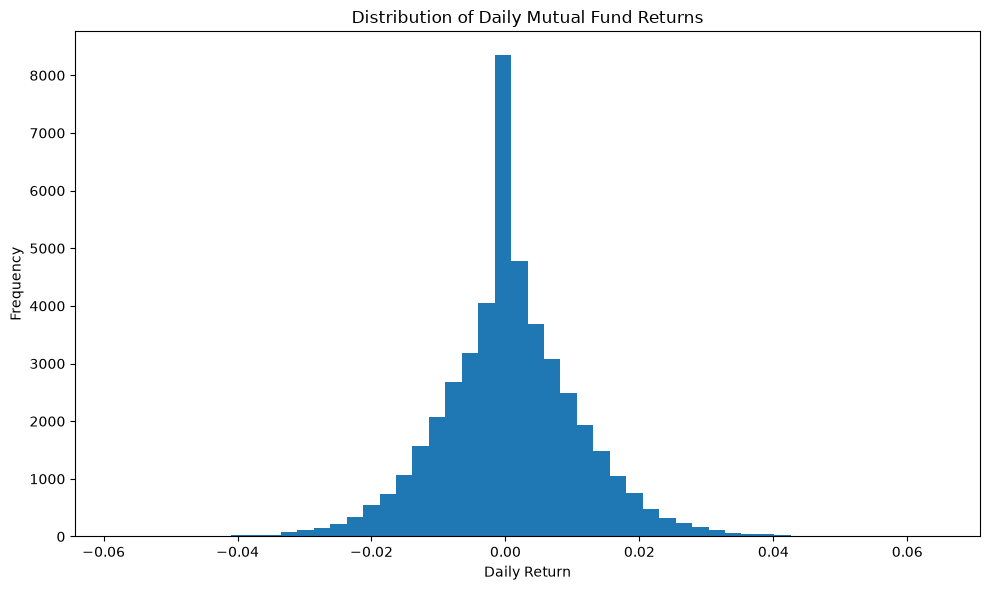

In [16]:
import matplotlib.pyplot as plt

returns = nav_df["daily_return"].dropna()

plt.figure(figsize=(10, 6))

plt.hist(
    returns,
    bins=50
)

plt.title("Distribution of Daily Mutual Fund Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

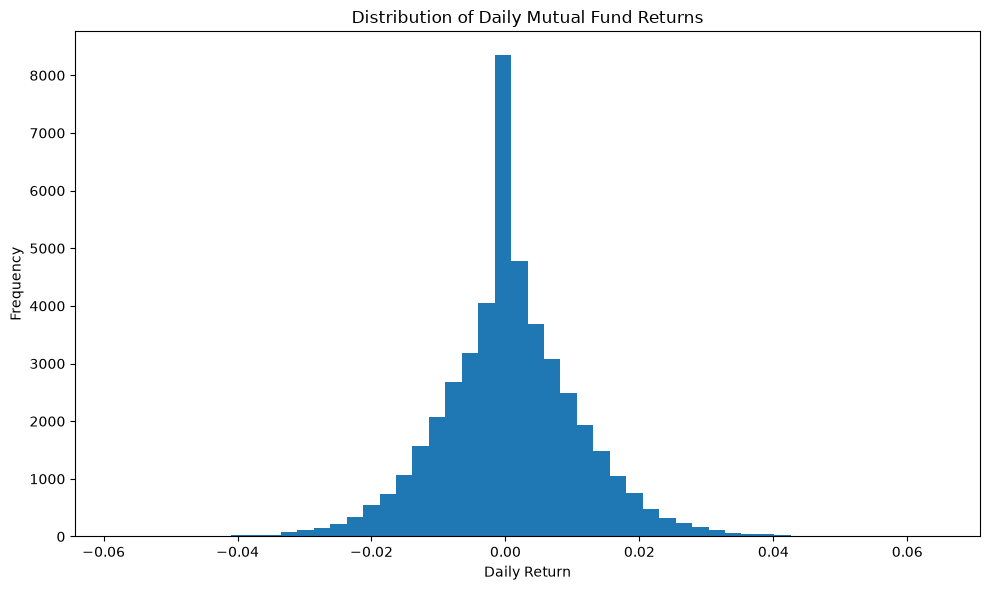

In [17]:
plt.figure(figsize=(10, 6))

plt.hist(
    returns,
    bins=50
)

plt.title("Distribution of Daily Mutual Fund Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
print("Minimum daily return:", returns.min())
print("Maximum daily return:", returns.max())
print("Mean daily return:", returns.mean())
print("Daily volatility:", returns.std())

Minimum daily return: -0.058102013949189124
Maximum daily return: 0.06471309359097144
Mean daily return: 0.0006310517590547711
Daily volatility: 0.010290414788248919


In [19]:
print("Number of unique funds:", nav_df["amfi_code"].nunique())

Number of unique funds: 40


In [20]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"].pct_change()
)

In [21]:
display(
    nav_df[
        ["amfi_code", "date", "nav", "daily_return"]
    ].head(15)
)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [22]:
print("Earliest NAV date:", nav_df["date"].min())
print("Latest NAV date:", nav_df["date"].max())

print("\nNumber of funds:")
print(nav_df["amfi_code"].nunique())

print("\nObservations per fund:")
display(
    nav_df.groupby("amfi_code")
    .size()
    .describe()
)

Earliest NAV date: 2022-01-03 00:00:00
Latest NAV date: 2026-05-29 00:00:00

Number of funds:
40

Observations per fund:


count      40.0
mean     1150.0
std         0.0
min      1150.0
25%      1150.0
50%      1150.0
75%      1150.0
max      1150.0
dtype: float64

In [23]:
fund_dates = nav_df.groupby("amfi_code")["date"].agg(
    ["min", "max", "count"]
)

display(fund_dates)

,min,max,count
amfi_code,,,
100016,2022-01-03,2026-05-29,1150
100025,2022-01-03,2026-05-29,1150
100033,2022-01-03,2026-05-29,1150
101206,2022-01-03,2026-05-29,1150
101207,2022-01-03,2026-05-29,1150
101208,2022-01-03,2026-05-29,1150
102885,2022-01-03,2026-05-29,1150
102886,2022-01-03,2026-05-29,1150
102887,2022-01-03,2026-05-29,1150


## 5. CAGR Analysis

CAGR measures the annualized growth rate of a mutual fund over a specified period.

Formula:

CAGR = (Ending NAV / Starting NAV)^(1/n) - 1

Where n represents the investment period in years.

In [24]:
from pandas.tseries.offsets import DateOffset

def calculate_cagr(data, years):
    results = []

    for fund_code, group in data.groupby("amfi_code"):
        group = group.sort_values("date").copy()

        end_date = group["date"].max()
        end_nav = group.iloc[-1]["nav"]

        target_date = end_date - DateOffset(years=years)

        # Find NAV closest to the target date
        eligible = group[group["date"] <= target_date]

        if len(eligible) == 0:
            results.append({
                "amfi_code": fund_code,
                f"{years}Y_CAGR": np.nan
            })
            continue

        start_row = eligible.iloc[-1]
        start_nav = start_row["nav"]

        actual_days = (end_date - start_row["date"]).days
        actual_years = actual_days / 365.25

        cagr = (end_nav / start_nav) ** (1 / actual_years) - 1

        results.append({
            "amfi_code": fund_code,
            f"{years}Y_CAGR": cagr
        })

    return pd.DataFrame(results)

In [25]:
cagr_1y = calculate_cagr(nav_df, 1)
cagr_3y = calculate_cagr(nav_df, 3)
cagr_5y = calculate_cagr(nav_df, 5)

In [26]:
cagr_table = (
    cagr_1y
    .merge(cagr_3y, on="amfi_code", how="outer")
    .merge(cagr_5y, on="amfi_code", how="outer")
)

display(cagr_table)

,amfi_code,1Y_CAGR,3Y_CAGR,5Y_CAGR
0,100016,-0.022258,0.012924,NaN
1,100025,0.037076,0.039155,NaN
2,100033,0.532772,0.324340,NaN
3,101206,0.479638,0.289602,NaN
4,101207,-0.240003,-0.041515,NaN
5,101208,0.072418,0.063143,NaN
6,102885,0.202229,0.196624,NaN
7,102886,-0.168080,-0.007672,NaN
8,102887,0.135930,0.255497,NaN
9,118632,0.340079,0.226466,NaN


In [27]:
print("1Y CAGR available:", cagr_table["1Y_CAGR"].notna().sum())
print("3Y CAGR available:", cagr_table["3Y_CAGR"].notna().sum())
print("5Y CAGR available:", cagr_table["5Y_CAGR"].notna().sum())

1Y CAGR available: 40
3Y CAGR available: 40
5Y CAGR available: 0


### Data Availability Note

The available NAV history spans from January 2022 to May 2026. Therefore, 1-year and 3-year CAGR calculations are available for all 40 schemes. A 5-year CAGR cannot be calculated from the available dataset because it does not contain five complete years of historical NAV observations. The 5-year CAGR values are therefore reported as unavailable rather than being estimated or fabricated.

## 6. Sharpe Ratio Analysis

The Sharpe Ratio measures risk-adjusted return by comparing the fund's excess return over the risk-free rate with its volatility.

Formula:

Sharpe Ratio = (Rp - Rf) / Std(Rp) × √252

Where:

- Rp = average daily fund return
- Rf = daily risk-free rate
- 252 = approximate number of trading days in a year

In [28]:
# Annual risk-free rate specified by the task
annual_rf = 0.065

# Convert annual risk-free rate to daily rate
daily_rf = (1 + annual_rf) ** (1 / 252) - 1

print("Annual risk-free rate:", annual_rf)
print("Daily risk-free rate:", daily_rf)

Annual risk-free rate: 0.065
Daily risk-free rate: 0.00024993122427763304


In [29]:
def calculate_sharpe(group):
    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        return np.nan

    excess_returns = returns - daily_rf

    sharpe = (
        excess_returns.mean()
        / returns.std()
    ) * np.sqrt(252)

    return sharpe


sharpe_table = (
    nav_df.groupby("amfi_code")
    .apply(calculate_sharpe, include_groups=False)
    .reset_index(name="Sharpe_Ratio")
)

display(sharpe_table)

,amfi_code,Sharpe_Ratio
0,100016,-0.187650
1,100025,-0.515438
2,100033,1.104352
3,101206,1.041061
4,101207,0.170481
5,101208,-0.417229
6,102885,0.832815
7,102886,-0.194707
8,102887,0.632319
9,118632,1.095918


In [30]:
sharpe_table["Sharpe_Rank"] = (
    sharpe_table["Sharpe_Ratio"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

sharpe_table = sharpe_table.sort_values(
    "Sharpe_Rank"
).reset_index(drop=True)

display(sharpe_table)

,amfi_code,Sharpe_Ratio,Sharpe_Rank
0,148567,1.462504,1
1,120843,1.319442,2
2,148569,1.246344,3
3,119551,1.222947,4
4,120505,1.190559,5
5,149323,1.143490,6
6,100033,1.104352,7
7,118632,1.095918,8
8,101206,1.041061,9
9,120504,1.040569,10


In [31]:
print("Number of funds:", len(sharpe_table))
print("Missing Sharpe values:", sharpe_table["Sharpe_Ratio"].isna().sum())
print("Rank 1 fund:")
display(sharpe_table.head(1))

Number of funds: 40
Missing Sharpe values: 0
Rank 1 fund:


,amfi_code,Sharpe_Ratio,Sharpe_Rank
0,148567,1.462504,1


## 6.1 Sharpe Ratio Ranking

The Sharpe Ratio is used to compare the risk-adjusted performance of the 40 mutual fund schemes. A higher Sharpe Ratio indicates better excess return relative to volatility.

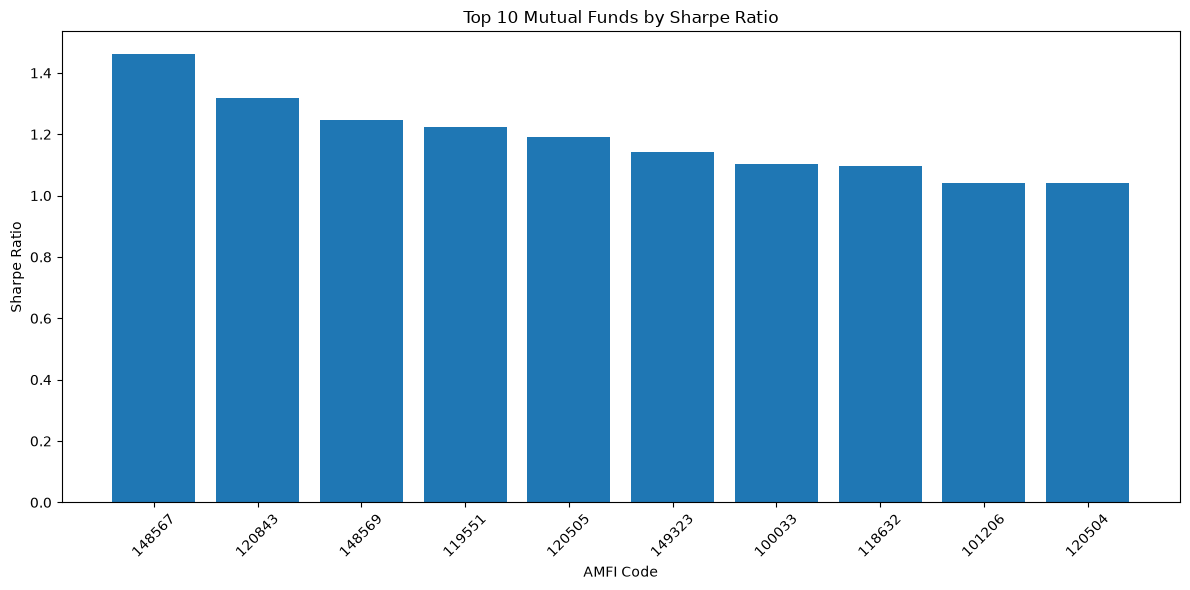

In [32]:
top10_sharpe = sharpe_table.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top10_sharpe["amfi_code"].astype(str),
    top10_sharpe["Sharpe_Ratio"]
)

plt.title("Top 10 Mutual Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

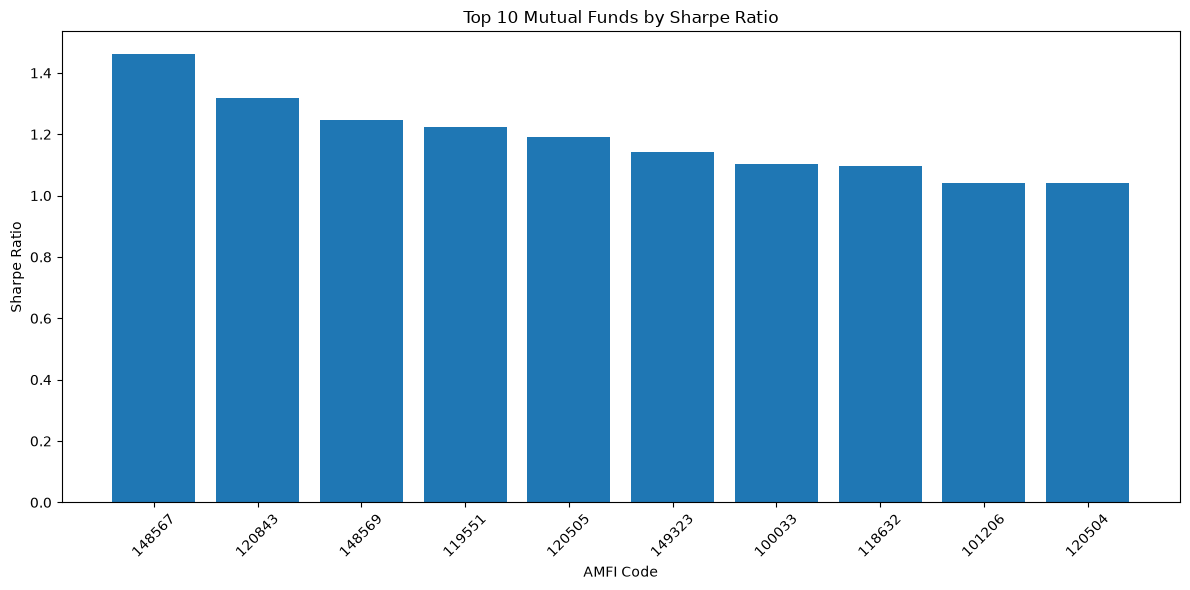

In [33]:
plt.figure(figsize=(12, 6))

plt.bar(
    top10_sharpe["amfi_code"].astype(str),
    top10_sharpe["Sharpe_Ratio"]
)

plt.title("Top 10 Mutual Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../reports/sharpe_ratio_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Sortino Ratio Analysis

The Sortino Ratio measures risk-adjusted performance using only downside volatility.

Unlike the Sharpe Ratio, which considers total volatility, the Sortino Ratio considers only negative return observations.

Formula:

Sortino Ratio = (Rp - Rf) / Downside Deviation × √252

Where:

- Rp = average daily fund return
- Rf = daily risk-free rate
- Downside Deviation = standard deviation of negative daily returns
- 252 = approximate number of trading days per year

In [34]:
def calculate_sortino(group):
    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        return np.nan

    # Only negative return days
    downside_returns = returns[returns < 0]

    if len(downside_returns) < 2:
        return np.nan

    # Downside standard deviation
    downside_std = downside_returns.std()

    # Average daily excess return
    excess_return = returns.mean() - daily_rf

    sortino = (
        excess_return / downside_std
    ) * np.sqrt(252)

    return sortino


sortino_table = (
    nav_df.groupby("amfi_code")
    .apply(calculate_sortino, include_groups=False)
    .reset_index(name="Sortino_Ratio")
)

display(sortino_table)

,amfi_code,Sortino_Ratio
0,100016,-0.326892
1,100025,-0.856030
2,100033,1.846950
3,101206,1.823822
4,101207,0.289943
5,101208,-0.859988
6,102885,1.463356
7,102886,-0.328457
8,102887,1.111253
9,118632,1.874521


In [35]:
sortino_table["Sortino_Rank"] = (
    sortino_table["Sortino_Ratio"]
    .rank(
        ascending=False,
        method="min"
    )
)

sortino_table = sortino_table.sort_values(
    "Sortino_Rank"
).reset_index(drop=True)

display(sortino_table)

,amfi_code,Sortino_Ratio,Sortino_Rank
0,148567,2.409056,1.0
1,120843,2.387295,2.0
2,148569,2.166757,3.0
3,119551,2.166272,4.0
4,120505,2.047336,5.0
5,120507,1.918995,6.0
6,149323,1.893929,7.0
7,118632,1.874521,8.0
8,100033,1.846950,9.0
9,120504,1.829993,10.0


In [36]:
print("Number of funds:", len(sortino_table))

print(
    "Missing Sortino values:",
    sortino_table["Sortino_Ratio"].isna().sum()
)

print("\nTop 10 funds by Sortino Ratio:")

display(sortino_table.head(10))

Number of funds: 40
Missing Sortino values: 0

Top 10 funds by Sortino Ratio:


,amfi_code,Sortino_Ratio,Sortino_Rank
0,148567,2.409056,1.0
1,120843,2.387295,2.0
2,148569,2.166757,3.0
3,119551,2.166272,4.0
4,120505,2.047336,5.0
5,120507,1.918995,6.0
6,149323,1.893929,7.0
7,118632,1.874521,8.0
8,100033,1.846950,9.0
9,120504,1.829993,10.0


## 7.1 Sortino Ratio Ranking

The following chart shows the top 10 funds ranked by Sortino Ratio. A higher Sortino Ratio indicates stronger return relative to downside risk.

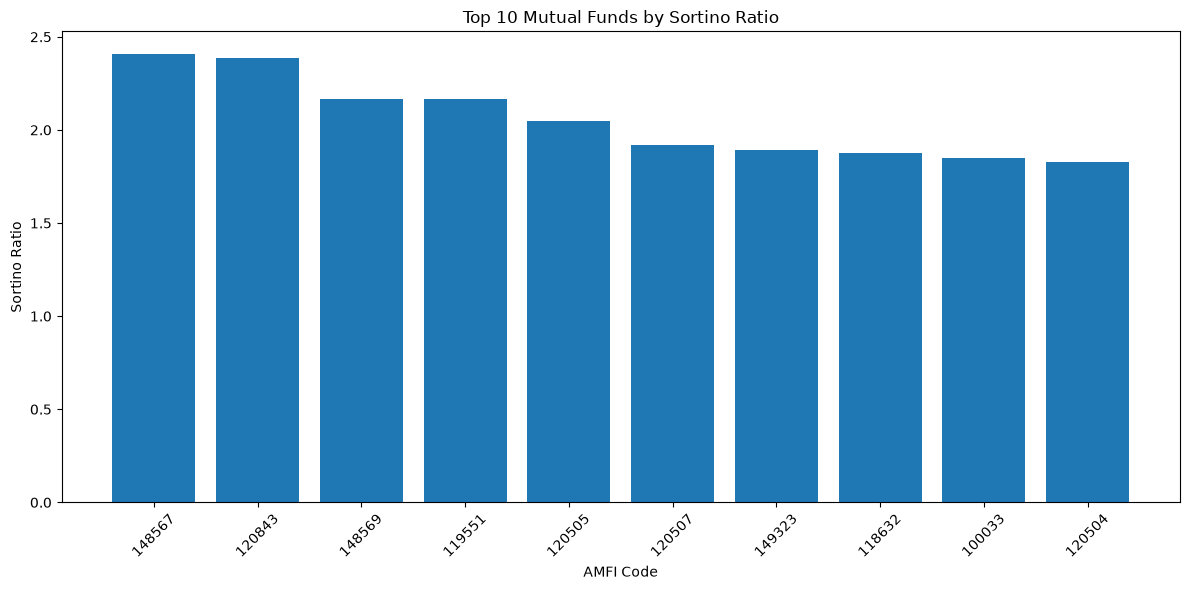

In [37]:
top10_sortino = sortino_table.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top10_sortino["amfi_code"].astype(str),
    top10_sortino["Sortino_Ratio"]
)

plt.title("Top 10 Mutual Funds by Sortino Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sortino Ratio")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

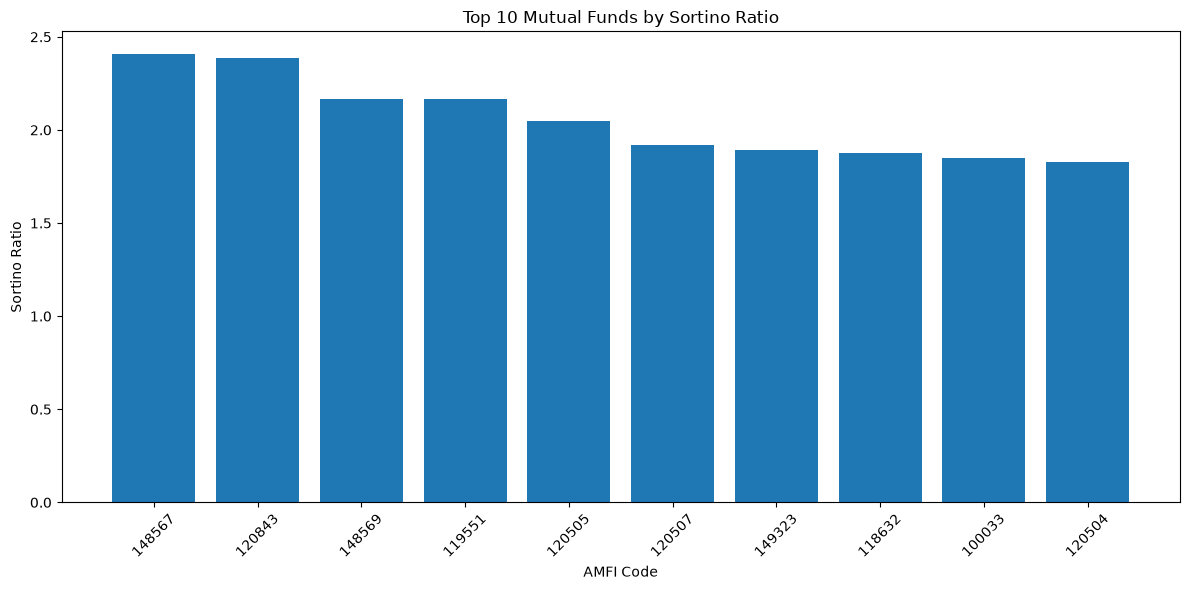

In [38]:
plt.figure(figsize=(12, 6))

plt.bar(
    top10_sortino["amfi_code"].astype(str),
    top10_sortino["Sortino_Ratio"]
)

plt.title("Top 10 Mutual Funds by Sortino Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sortino Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/sortino_ratio_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# Load benchmark data

benchmark_df = pd.read_csv(
    "../data/processed/10_benchmark_indices.csv"
)

print("Shape:", benchmark_df.shape)

print("\nColumns:")
print(benchmark_df.columns.tolist())

print("\nFirst 10 rows:")
display(benchmark_df.head(10))

Shape: (8050, 3)

Columns:
['date', 'index_name', 'close_value']

First 10 rows:


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15
5,2022-01-10,NIFTY50,18124.84
6,2022-01-11,NIFTY50,18256.96
7,2022-01-12,NIFTY50,18162.54
8,2022-01-13,NIFTY50,18179.05
9,2022-01-14,NIFTY50,17971.75


In [40]:
print("Available benchmark indices:")

display(
    benchmark_df["index_name"]
    .dropna()
    .unique()
)

Available benchmark indices:


<ArrowStringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [41]:
# Prepare Nifty 100 benchmark data

nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"],
    errors="coerce"
)

nifty100["close_value"] = pd.to_numeric(
    nifty100["close_value"],
    errors="coerce"
)

nifty100 = nifty100.dropna(
    subset=["date", "close_value"]
)

nifty100 = nifty100.sort_values("date").reset_index(drop=True)

print("Nifty 100 observations:", len(nifty100))
print("Start date:", nifty100["date"].min())
print("End date:", nifty100["date"].max())

display(nifty100.head())

Nifty 100 observations: 1150
Start date: 2022-01-03 00:00:00
End date: 2026-05-29 00:00:00


,date,index_name,close_value
0,2022-01-03,NIFTY100,17778.24
1,2022-01-04,NIFTY100,17537.52
2,2022-01-05,NIFTY100,17607.73
3,2022-01-06,NIFTY100,17556.05
4,2022-01-07,NIFTY100,17664.02


In [42]:
nifty100["nifty100_return"] = (
    nifty100["close_value"].pct_change()
)

display(nifty100.head(10))

,date,index_name,close_value,nifty100_return
0,2022-01-03,NIFTY100,17778.24,NaN
1,2022-01-04,NIFTY100,17537.52,-0.013540
2,2022-01-05,NIFTY100,17607.73,0.004003
3,2022-01-06,NIFTY100,17556.05,-0.002935
4,2022-01-07,NIFTY100,17664.02,0.006150
5,2022-01-10,NIFTY100,17516.51,-0.008351
6,2022-01-11,NIFTY100,17603.08,0.004942
7,2022-01-12,NIFTY100,17763.76,0.009128
8,2022-01-13,NIFTY100,17830.30,0.003746
9,2022-01-14,NIFTY100,17578.93,-0.014098


In [43]:
fund_returns = nav_df[
    ["amfi_code", "date", "daily_return"]
].copy()

fund_returns = fund_returns.dropna(
    subset=["daily_return"]
)

display(fund_returns.head())

,amfi_code,date,daily_return
1,100016,2022-01-04,-0.010306
2,100016,2022-01-05,0.012865
3,100016,2022-01-06,-0.011377
4,100016,2022-01-07,-0.001210
5,100016,2022-01-10,-0.008639


In [44]:
regression_data = fund_returns.merge(
    nifty100[
        ["date", "nifty100_return"]
    ],
    on="date",
    how="inner"
)

regression_data = regression_data.dropna(
    subset=["daily_return", "nifty100_return"]
)

print("Regression dataset shape:", regression_data.shape)

display(regression_data.head())

Regression dataset shape: (45960, 4)


,amfi_code,date,daily_return,nifty100_return
0,100016,2022-01-04,-0.010306,-0.013540
1,100016,2022-01-05,0.012865,0.004003
2,100016,2022-01-06,-0.011377,-0.002935
3,100016,2022-01-07,-0.001210,0.006150
4,100016,2022-01-10,-0.008639,-0.008351


## 8.1 OLS Regression Against Nifty 100

For each mutual fund, an OLS regression is performed using:

Fund Return = Intercept + Beta × Nifty 100 Return

Beta is the regression slope.

Annualized Alpha is calculated as:

Alpha = Intercept × 252

The regression is implemented using scipy.stats.linregress as specified in the task.

In [45]:
from scipy.stats import linregress

alpha_beta_results = []

for fund_code, group in regression_data.groupby("amfi_code"):
    
    x = group["nifty100_return"].values
    y = group["daily_return"].values
    
    if len(x) < 2:
        continue
    
    regression = linregress(x, y)
    
    beta = regression.slope
    intercept = regression.intercept
    alpha = intercept * 252
    
    alpha_beta_results.append({
        "amfi_code": fund_code,
        "Alpha": alpha,
        "Beta": beta,
        "R_Squared": regression.rvalue ** 2,
        "Observations": len(group)
    })

alpha_beta = pd.DataFrame(alpha_beta_results)

display(alpha_beta)

,amfi_code,Alpha,Beta,R_Squared,Observations
0,100016,0.037476,-0.058268,2.665033e-03,1149
1,100025,0.042818,0.001158,1.461284e-05,1149
2,100033,0.271954,0.005104,1.206652e-05,1149
3,101206,0.213998,0.021086,3.480482e-04,1149
4,101207,0.108971,-0.065289,1.064105e-03,1149
5,101208,0.060861,0.000267,4.607624e-05,1149
6,102885,0.170488,-0.019487,3.828503e-04,1149
7,102886,0.028969,-0.042125,8.964295e-04,1149
8,102887,0.162113,0.016683,1.861917e-04,1149
9,118632,0.218294,-0.008354,5.791756e-05,1149


In [46]:
print("Number of funds:", len(alpha_beta))

print(
    "Missing Alpha:",
    alpha_beta["Alpha"].isna().sum()
)

print(
    "Missing Beta:",
    alpha_beta["Beta"].isna().sum()
)

Number of funds: 40
Missing Alpha: 0
Missing Beta: 0


In [47]:
alpha_beta = alpha_beta.sort_values(
    "Alpha",
    ascending=False
).reset_index(drop=True)

display(alpha_beta)

,amfi_code,Alpha,Beta,R_Squared,Observations
0,119598,0.303370,-0.023196,1.414258e-04,1149
1,149324,0.300579,0.011455,3.532991e-05,1149
2,120505,0.292636,0.000549,1.345534e-07,1149
3,148569,0.282704,0.018134,1.748889e-04,1149
4,120843,0.273305,-0.022830,3.430543e-04,1149
5,100033,0.271954,0.005104,1.206652e-05,1149
6,148567,0.269838,0.023684,4.625437e-04,1149
7,149323,0.265986,-0.002523,3.357978e-06,1149
8,119094,0.260767,-0.066265,1.936879e-03,1149
9,119551,0.232010,-0.031751,8.869789e-04,1149


In [48]:
alpha_beta.to_csv(
    "../alpha_beta.csv",
    index=False
)

print("alpha_beta.csv created successfully.")

alpha_beta.csv created successfully.


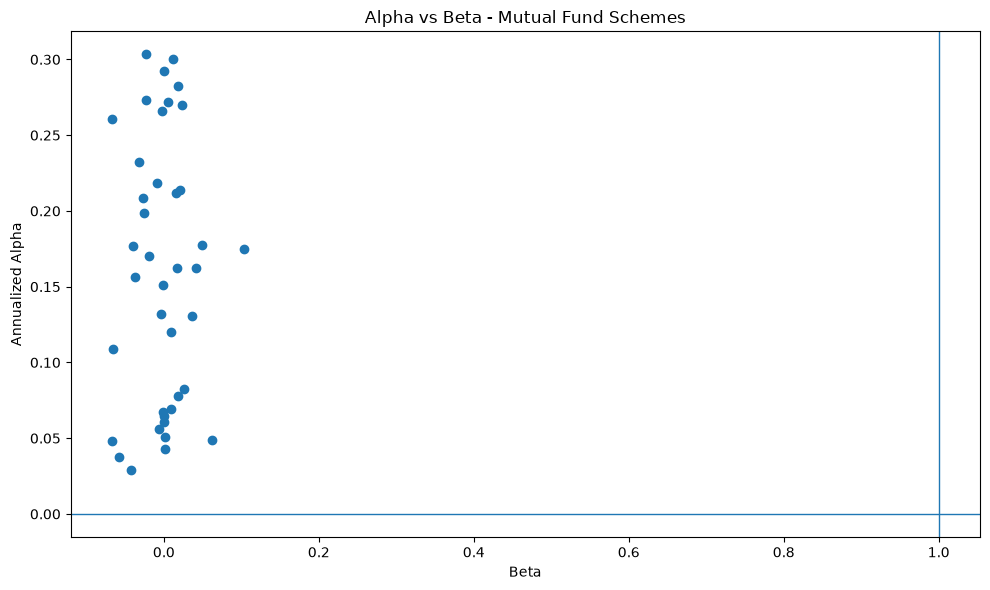

In [51]:
plt.figure(figsize=(10, 6))

plt.scatter(
    alpha_beta["Beta"],
    alpha_beta["Alpha"]
)

plt.title("Alpha vs Beta - Mutual Fund Schemes")
plt.xlabel("Beta")
plt.ylabel("Annualized Alpha")

plt.axhline(0, linewidth=1)
plt.axvline(1, linewidth=1)

plt.tight_layout()
plt.show()

In [50]:
print("Alpha range:")
print(alpha_beta["Alpha"].min(), alpha_beta["Alpha"].max())

print("\nBeta range:")
print(alpha_beta["Beta"].min(), alpha_beta["Beta"].max())

print("\nTop 10 by Alpha:")
display(alpha_beta.head(10))

Alpha range:
0.02896939786637944 0.3033696538698332

Beta range:
-0.06695117463929198 0.10349663691337589

Top 10 by Alpha:


,amfi_code,Alpha,Beta,R_Squared,Observations
0,119598,0.303370,-0.023196,1.414258e-04,1149
1,149324,0.300579,0.011455,3.532991e-05,1149
2,120505,0.292636,0.000549,1.345534e-07,1149
3,148569,0.282704,0.018134,1.748889e-04,1149
4,120843,0.273305,-0.022830,3.430543e-04,1149
5,100033,0.271954,0.005104,1.206652e-05,1149
6,148567,0.269838,0.023684,4.625437e-04,1149
7,149323,0.265986,-0.002523,3.357978e-06,1149
8,119094,0.260767,-0.066265,1.936879e-03,1149
9,119551,0.232010,-0.031751,8.869789e-04,1149


In [52]:
display(alpha_beta)

,amfi_code,Alpha,Beta,R_Squared,Observations
0,119598,0.303370,-0.023196,1.414258e-04,1149
1,149324,0.300579,0.011455,3.532991e-05,1149
2,120505,0.292636,0.000549,1.345534e-07,1149
3,148569,0.282704,0.018134,1.748889e-04,1149
4,120843,0.273305,-0.022830,3.430543e-04,1149
5,100033,0.271954,0.005104,1.206652e-05,1149
6,148567,0.269838,0.023684,4.625437e-04,1149
7,149323,0.265986,-0.002523,3.357978e-06,1149
8,119094,0.260767,-0.066265,1.936879e-03,1149
9,119551,0.232010,-0.031751,8.869789e-04,1149


In [53]:
print("Nifty 100 return statistics:")
display(nifty100["nifty100_return"].describe())

Nifty 100 return statistics:


count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: nifty100_return, dtype: float64

In [54]:
print("Nifty 100 return standard deviation:")
print(nifty100["nifty100_return"].std())

print("\nNifty 100 minimum return:")
print(nifty100["nifty100_return"].min())

print("\nNifty 100 maximum return:")
print(nifty100["nifty100_return"].max())

Nifty 100 return standard deviation:
0.008119419678050336

Nifty 100 minimum return:
-0.02687297405965361

Nifty 100 maximum return:
0.02679498136974412


In [55]:
print("Mutual fund return statistics:")
display(nav_df["daily_return"].describe())

Mutual fund return statistics:


count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [56]:
display(
    regression_data[
        ["amfi_code", "date", "daily_return", "nifty100_return"]
    ].head(20)
)

,amfi_code,date,daily_return,nifty100_return
0,100016,2022-01-04,-0.010306,-0.013540
1,100016,2022-01-05,0.012865,0.004003
2,100016,2022-01-06,-0.011377,-0.002935
3,100016,2022-01-07,-0.001210,0.006150
4,100016,2022-01-10,-0.008639,-0.008351
5,100016,2022-01-11,0.005562,0.004942
6,100016,2022-01-12,-0.002404,0.009128
7,100016,2022-01-13,-0.004050,0.003746
8,100016,2022-01-14,0.008073,-0.014098
9,100016,2022-01-17,0.000776,0.020825


In [57]:
test_fund = regression_data[
    regression_data["amfi_code"] == 119598
].copy()

print("Observations:", len(test_fund))

print(
    "Correlation:",
    test_fund["daily_return"].corr(
        test_fund["nifty100_return"]
    )
)

Observations: 1149
Correlation: -0.01189225609492232


In [58]:
display(
    test_fund[
        ["date", "daily_return", "nifty100_return"]
    ].head(20)
)

,date,daily_return,nifty100_return
24129,2022-01-04,-0.014735,-0.013540
24130,2022-01-05,-0.005161,0.004003
24131,2022-01-06,0.004824,-0.002935
24132,2022-01-07,0.032830,0.006150
24133,2022-01-10,0.051113,-0.008351
24134,2022-01-11,0.010483,0.004942
24135,2022-01-12,-0.002010,0.009128
24136,2022-01-13,0.009334,0.003746
24137,2022-01-14,0.014963,-0.014098
24138,2022-01-17,-0.004168,0.020825


In [59]:
display(
    nifty100[
        ["date", "close_value", "nifty100_return"]
    ].head(20)
)

,date,close_value,nifty100_return
0,2022-01-03,17778.24,NaN
1,2022-01-04,17537.52,-0.013540
2,2022-01-05,17607.73,0.004003
3,2022-01-06,17556.05,-0.002935
4,2022-01-07,17664.02,0.006150
5,2022-01-10,17516.51,-0.008351
6,2022-01-11,17603.08,0.004942
7,2022-01-12,17763.76,0.009128
8,2022-01-13,17830.30,0.003746
9,2022-01-14,17578.93,-0.014098


In [60]:
print(
    "Unique Nifty 100 dates:",
    nifty100["date"].nunique()
)

print(
    "Nifty 100 rows:",
    len(nifty100)
)

Unique Nifty 100 dates: 1150
Nifty 100 rows: 1150


In [61]:
print("Nifty 100 return statistics:")
display(nifty100["nifty100_return"].describe())

print("\nNifty 100 standard deviation:")
print(nifty100["nifty100_return"].std())

Nifty 100 return statistics:


count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: nifty100_return, dtype: float64


Nifty 100 standard deviation:
0.008119419678050336


In [62]:
display(
    regression_data[
        ["amfi_code", "date", "daily_return", "nifty100_return"]
    ].head(20)
)

,amfi_code,date,daily_return,nifty100_return
0,100016,2022-01-04,-0.010306,-0.013540
1,100016,2022-01-05,0.012865,0.004003
2,100016,2022-01-06,-0.011377,-0.002935
3,100016,2022-01-07,-0.001210,0.006150
4,100016,2022-01-10,-0.008639,-0.008351
5,100016,2022-01-11,0.005562,0.004942
6,100016,2022-01-12,-0.002404,0.009128
7,100016,2022-01-13,-0.004050,0.003746
8,100016,2022-01-14,0.008073,-0.014098
9,100016,2022-01-17,0.000776,0.020825


In [63]:
test_fund = regression_data[
    regression_data["amfi_code"] == 119598
].copy()

print("Fund 119598 observations:", len(test_fund))

print(
    "Correlation with Nifty 100:",
    test_fund["daily_return"].corr(
        test_fund["nifty100_return"]
    )
)

Fund 119598 observations: 1149
Correlation with Nifty 100: -0.01189225609492232


In [64]:
display(
    test_fund[
        ["date", "daily_return", "nifty100_return"]
    ].head(20)
)

,date,daily_return,nifty100_return
24129,2022-01-04,-0.014735,-0.013540
24130,2022-01-05,-0.005161,0.004003
24131,2022-01-06,0.004824,-0.002935
24132,2022-01-07,0.032830,0.006150
24133,2022-01-10,0.051113,-0.008351
24134,2022-01-11,0.010483,0.004942
24135,2022-01-12,-0.002010,0.009128
24136,2022-01-13,0.009334,0.003746
24137,2022-01-14,0.014963,-0.014098
24138,2022-01-17,-0.004168,0.020825


## 9. Maximum Drawdown Analysis

Maximum Drawdown measures the largest decline in NAV from a previous peak to a subsequent trough.

Formula:

Drawdown = NAV / Running Maximum NAV - 1

Maximum Drawdown = minimum Drawdown

The peak date and trough date are also identified for each fund.

In [65]:
# Prepare NAV data for drawdown analysis

drawdown_results = []

for fund_code, group in nav_df.groupby("amfi_code"):
    
    group = group.sort_values("date").copy()
    
    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()
    
    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1
    
    # Find maximum drawdown
    min_idx = group["drawdown"].idxmin()
    
    max_drawdown = group.loc[min_idx, "drawdown"]
    trough_date = group.loc[min_idx, "date"]
    trough_nav = group.loc[min_idx, "nav"]
    
    # Running peak immediately before or at trough
    peak_nav = group.loc[min_idx, "running_max"]
    
    # Find the date when that peak NAV occurred
    peak_rows = group[
        group["nav"] == peak_nav
    ]
    
    peak_date = peak_rows["date"].iloc[-1]
    
    drawdown_results.append({
        "amfi_code": fund_code,
        "Max_Drawdown": max_drawdown,
        "Peak_Date": peak_date,
        "Trough_Date": trough_date,
        "Peak_NAV": peak_nav,
        "Trough_NAV": trough_nav
    })

drawdown_table = pd.DataFrame(drawdown_results)

display(drawdown_table)

,amfi_code,Max_Drawdown,Peak_Date,Trough_Date,Peak_NAV,Trough_NAV
0,100016,-0.247344,2022-03-30,2022-09-15,546.3002,411.1759
1,100025,-0.043083,2023-05-23,2023-07-28,28.7494,27.5108
2,100033,-0.162172,2022-03-11,2022-05-12,111.6641,93.5553
3,101206,-0.112916,2023-04-24,2023-07-05,370.0026,328.2234
4,101207,-0.354469,2024-11-21,2026-05-11,80.3517,51.8695
5,101208,-0.001622,2023-09-05,2023-09-12,346.9958,346.4328
6,102885,-0.108599,2022-02-03,2022-03-29,93.7848,83.5999
7,102886,-0.280011,2025-01-07,2026-04-27,169.8164,122.2659
8,102887,-0.215398,2022-01-03,2022-07-04,191.0721,149.9155
9,118632,-0.174141,2024-01-02,2024-07-19,81.9320,67.6643


In [66]:
print("Number of funds:", len(drawdown_table))

print(
    "Missing maximum drawdowns:",
    drawdown_table["Max_Drawdown"].isna().sum()
)

Number of funds: 40
Missing maximum drawdowns: 0


In [67]:
drawdown_table = drawdown_table.sort_values(
    "Max_Drawdown",
    ascending=True
).reset_index(drop=True)

display(drawdown_table)

,amfi_code,Max_Drawdown,Peak_Date,Trough_Date,Peak_NAV,Trough_NAV
0,119599,-0.525742,2023-01-17,2025-10-28,165.7647,78.6152
1,119095,-0.516778,2025-05-22,2026-05-11,106.8214,51.6185
2,101207,-0.354469,2024-11-21,2026-05-11,80.3517,51.8695
3,149324,-0.311719,2024-05-03,2025-01-03,174.4645,120.0806
4,119598,-0.287060,2024-08-28,2025-05-14,225.2452,160.5863
5,102886,-0.280011,2025-01-07,2026-04-27,169.8164,122.2659
6,100016,-0.247344,2022-03-30,2022-09-15,546.3002,411.1759
7,120842,-0.240035,2023-11-09,2024-10-17,80.0837,60.8608
8,118634,-0.233449,2025-04-09,2026-02-20,126.7224,97.1392
9,119093,-0.217514,2022-02-24,2023-05-22,42.2166,33.0339


In [68]:
drawdown_table["Max_DD_Rank"] = (
    drawdown_table["Max_Drawdown"]
    .rank(
        ascending=False,
        method="min"
    )
)

In [69]:
print("Best 10 funds by maximum drawdown:")

display(
    drawdown_table.sort_values(
        "Max_Drawdown",
        ascending=False
    ).head(10)
)

Best 10 funds by maximum drawdown:


,amfi_code,Max_Drawdown,Peak_Date,Trough_Date,Peak_NAV,Trough_NAV,Max_DD_Rank
39,120507,-0.000977,2025-10-16,2025-10-20,372.0401,371.6765,1.0
38,120844,-0.001163,2024-04-12,2024-04-30,3738.8231,3734.4751,2.0
37,101208,-0.001622,2023-09-05,2023-09-12,346.9958,346.4328,3.0
36,100025,-0.043083,2023-05-23,2023-07-28,28.7494,27.5108,4.0
35,119120,-0.043287,2024-09-16,2025-04-01,52.5004,50.2278,5.0
34,118636,-0.083164,2023-02-09,2024-02-09,34.1748,31.3327,6.0
33,102885,-0.108599,2022-02-03,2022-03-29,93.7848,83.5999,7.0
32,148567,-0.112657,2023-07-11,2023-10-20,101.8496,90.3755,8.0
31,101206,-0.112916,2023-04-24,2023-07-05,370.0026,328.2234,9.0
30,118635,-0.116506,2022-01-03,2022-06-09,170.3428,150.4968,10.0


In [70]:
worst_drawdown = drawdown_table.sort_values(
    "Max_Drawdown"
).iloc[0]

print("Worst drawdown fund:", worst_drawdown["amfi_code"])
print("Maximum Drawdown:", worst_drawdown["Max_Drawdown"])
print("Peak Date:", worst_drawdown["Peak_Date"])
print("Trough Date:", worst_drawdown["Trough_Date"])

Worst drawdown fund: 119599
Maximum Drawdown: -0.5257422117012851
Peak Date: 2023-01-17 00:00:00
Trough Date: 2025-10-28 00:00:00


In [71]:
drawdown_table.to_csv(
    "../drawdown_analysis.csv",
    index=False
)

print("drawdown_analysis.csv created successfully.")

drawdown_analysis.csv created successfully.


## 9.1 Maximum Drawdown Ranking

The chart below shows the maximum drawdown of the top 10 funds. Smaller negative drawdowns indicate better downside protection.

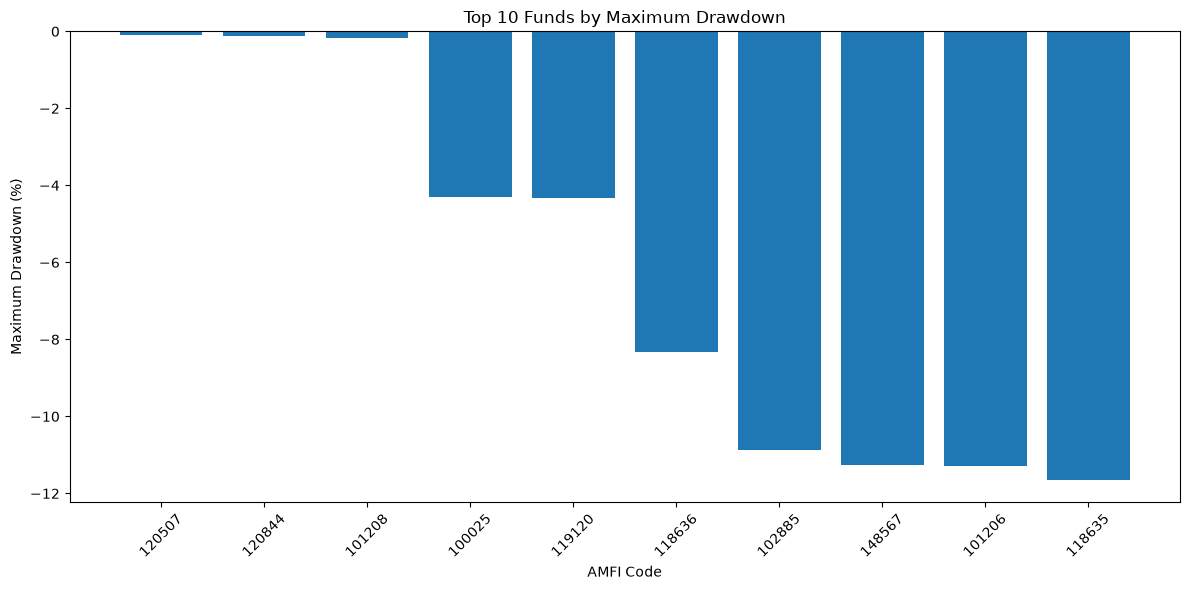

In [72]:
top10_drawdown = drawdown_table.sort_values(
    "Max_Drawdown",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top10_drawdown["amfi_code"].astype(str),
    top10_drawdown["Max_Drawdown"] * 100
)

plt.title("Top 10 Funds by Maximum Drawdown")
plt.xlabel("AMFI Code")
plt.ylabel("Maximum Drawdown (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [73]:
fund_master = pd.read_csv(
    "../data/processed/01_fund_master.csv"
)

print("Fund master shape:", fund_master.shape)

print("\nColumns:")
print(fund_master.columns.tolist())

display(fund_master.head())

Fund master shape: (40, 15)

Columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [78]:
# ============================================
# 10. FUND SCORECARD (0-100)
# ============================================

# Start with 3Y CAGR
scorecard = cagr_table[
    ["amfi_code", "3Y_CAGR"]
].copy()

# Add Sharpe Ratio
scorecard = scorecard.merge(
    sharpe_table[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code",
    how="left"
)

# Add Alpha
scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "Alpha"]],
    on="amfi_code",
    how="left"
)

# Add Maximum Drawdown
scorecard = scorecard.merge(
    drawdown_table[["amfi_code", "Max_Drawdown"]],
    on="amfi_code",
    how="left"
)

# Add Expense Ratio
scorecard = scorecard.merge(
    fund_master[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code",
    how="left"
)

# Add fund details
scorecard = scorecard.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)

print("Scorecard shape:", scorecard.shape)

display(scorecard.head(10))

Scorecard shape: (40, 8)


,amfi_code,3Y_CAGR,Sharpe_Ratio,Alpha,Max_Drawdown,expense_ratio_pct,scheme_name,fund_house
0,100016,0.012924,-0.187650,0.037476,-0.247344,1.55,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,0.039155,-0.515438,0.042818,-0.043083,0.56,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,0.324340,1.104352,0.271954,-0.162172,1.38,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,0.289602,1.041061,0.213998,-0.112916,1.60,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,-0.041515,0.170481,0.108971,-0.354469,1.53,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF
5,101208,0.063143,-0.417229,0.060861,-0.001622,0.79,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF
6,102885,0.196624,0.832815,0.170488,-0.108599,1.57,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund
7,102886,-0.007672,-0.194707,0.028969,-0.280011,1.51,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund
8,102887,0.255497,0.632319,0.162113,-0.215398,1.64,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund
9,118632,0.226466,1.095918,0.218294,-0.174141,1.51,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF


In [75]:
[name for name in globals() if "drawdown" in name.lower()]

['drawdown_results',
 'max_drawdown',
 'drawdown_table',
 'worst_drawdown',
 'top10_drawdown']

In [76]:
drawdown_table[["amfi_code", "Max_Drawdown"]]

,amfi_code,Max_Drawdown
0,119599,-0.525742
1,119095,-0.516778
2,101207,-0.354469
3,149324,-0.311719
4,119598,-0.287060
5,102886,-0.280011
6,100016,-0.247344
7,120842,-0.240035
8,118634,-0.233449
9,119093,-0.217514


In [79]:
# ============================================
# 10.1 SCORECARD RANKINGS
# ============================================

scorecard["CAGR_Rank"] = scorecard["3Y_CAGR"].rank(
    ascending=False,
    method="min"
)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(
    ascending=False,
    method="min"
)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(
    ascending=False,
    method="min"
)

# Lower expense ratio = better
scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True,
    method="min"
)

# Higher maximum drawdown value = better
# -5% is better than -12%
scorecard["Drawdown_Rank"] = scorecard["Max_Drawdown"].rank(
    ascending=False,
    method="min"
)

display(
    scorecard[
        [
            "amfi_code",
            "scheme_name",
            "CAGR_Rank",
            "Sharpe_Rank",
            "Alpha_Rank",
            "Expense_Rank",
            "Drawdown_Rank"
        ]
    ].head(10)
)

,amfi_code,scheme_name,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,35.0,36.0,39.0,32.0,34.0
1,100025,HDFC Short Term Debt Fund - Regular - Growth,34.0,40.0,38.0,2.0,4.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,4.0,7.0,6.0,16.0,20.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,9.0,9.0,12.0,36.0,9.0
4,101207,ABSL Small Cap Fund - Regular - Growth,39.0,29.0,27.0,28.0,38.0
5,101208,ABSL Liquid Fund - Regular - Growth,31.0,39.0,33.0,11.0,3.0
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,18.0,17.0,19.0,34.0,7.0
7,102886,UTI Mid Cap Fund - Regular - Growth,37.0,37.0,40.0,24.0,35.0
8,102887,UTI Flexi Cap Fund - Regular - Growth,13.0,23.0,21.0,39.0,30.0
9,118632,Nippon India Large Cap Fund - Regular - Growth,14.0,8.0,11.0,24.0,23.0


In [80]:
# ============================================
# 10.2 FINAL FUND SCORE (0-100)
# ============================================

n = len(scorecard)

# Convert rank into a 0-100 score
# Rank 1 = 100 points
# Rank 40 = 0 points
def rank_to_score(rank):
    return ((n - rank) / (n - 1)) * 100


scorecard["CAGR_Score"] = scorecard["CAGR_Rank"].apply(rank_to_score)
scorecard["Sharpe_Score"] = scorecard["Sharpe_Rank"].apply(rank_to_score)
scorecard["Alpha_Score"] = scorecard["Alpha_Rank"].apply(rank_to_score)
scorecard["Expense_Score"] = scorecard["Expense_Rank"].apply(rank_to_score)
scorecard["Drawdown_Score"] = scorecard["Drawdown_Rank"].apply(rank_to_score)


# Weighted Fund Score
scorecard["Fund_Score"] = (
    0.30 * scorecard["CAGR_Score"]
    + 0.25 * scorecard["Sharpe_Score"]
    + 0.20 * scorecard["Alpha_Score"]
    + 0.15 * scorecard["Expense_Score"]
    + 0.10 * scorecard["Drawdown_Score"]
)


# Final ranking
scorecard["Final_Rank"] = scorecard["Fund_Score"].rank(
    ascending=False,
    method="min"
)


# Sort from best to worst
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
).reset_index(drop=True)


# Display final ranking
display(
    scorecard[
        [
            "Final_Rank",
            "amfi_code",
            "scheme_name",
            "3Y_CAGR",
            "Sharpe_Ratio",
            "Alpha",
            "expense_ratio_pct",
            "Max_Drawdown",
            "Fund_Score"
        ]
    ]
)

,Final_Rank,amfi_code,scheme_name,3Y_CAGR,Sharpe_Ratio,Alpha,expense_ratio_pct,Max_Drawdown,Fund_Score
0,1.0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.339920,1.462504,0.269838,1.46,-0.112657,85.897436
1,2.0,120505,ICICI Pru Midcap Fund - Regular - Growth,0.317692,1.190559,0.292636,1.36,-0.181885,81.794872
2,3.0,120843,Kotak Flexicap Fund - Regular - Growth,0.295751,1.319442,0.273305,1.45,-0.129740,81.538462
3,4.0,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.324340,1.104352,0.271954,1.38,-0.162172,80.641026
4,5.0,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.324789,1.040569,0.211948,0.80,-0.125883,79.487179
5,6.0,119094,Axis Midcap Fund - Regular - Growth,0.351025,1.008626,0.260767,1.38,-0.209609,76.794872
6,7.0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.304486,1.222947,0.232010,1.54,-0.150124,74.358974
7,8.0,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.291714,1.246344,0.282704,1.60,-0.163967,73.205128
8,9.0,101206,ABSL Frontline Equity Fund - Regular - Growth,0.289602,1.041061,0.213998,1.60,-0.112916,67.564103
9,10.0,119598,SBI Small Cap Fund - Regular Plan - Growth,0.266631,0.953332,0.303370,1.43,-0.287060,66.538462


In [81]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv created successfully")

fund_scorecard.csv created successfully


In [82]:
# ============================================
# 11. TOP 5 FUNDS FOR BENCHMARK COMPARISON
# ============================================

top5_funds = scorecard.head(5)[
    ["Final_Rank", "amfi_code", "scheme_name", "Fund_Score"]
].copy()

display(top5_funds)

,Final_Rank,amfi_code,scheme_name,Fund_Score
0,1.0,148567,Mirae Asset Large Cap Fund - Regular - Growth,85.897436
1,2.0,120505,ICICI Pru Midcap Fund - Regular - Growth,81.794872
2,3.0,120843,Kotak Flexicap Fund - Regular - Growth,81.538462
3,4.0,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.641026
4,5.0,120504,ICICI Pru Bluechip Fund - Direct - Growth,79.487179


In [83]:
# ============================================
# 11.1 BENCHMARK DAILY RETURNS
# ============================================

benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

# Sort data
benchmark_df = benchmark_df.sort_values(
    ["index_name", "date"]
).copy()

# Calculate daily benchmark returns
benchmark_df["benchmark_return"] = (
    benchmark_df.groupby("index_name")["close_value"]
    .pct_change()
)

# Keep only Nifty 50 and Nifty 100
benchmark_returns = benchmark_df[
    benchmark_df["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

print("Benchmark names:")
print(benchmark_returns["index_name"].unique())

display(benchmark_returns.head(10))

Benchmark names:
<ArrowStringArray>
['NIFTY100', 'NIFTY50']
Length: 2, dtype: str


,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351
1156,2022-01-11,NIFTY100,17603.08,0.004942
1157,2022-01-12,NIFTY100,17763.76,0.009128
1158,2022-01-13,NIFTY100,17830.30,0.003746
1159,2022-01-14,NIFTY100,17578.93,-0.014098


In [84]:
# ============================================
# 11.2 LAST 3 YEARS PERIOD
# ============================================

nav_df["date"] = pd.to_datetime(nav_df["date"])

end_date = nav_df["date"].max()
start_date = end_date - pd.DateOffset(years=3)

print("Benchmark comparison period:")
print("Start date:", start_date.date())
print("End date:", end_date.date())

Benchmark comparison period:
Start date: 2023-05-29
End date: 2026-05-29


In [85]:
# ============================================
# 11.3 FUND DAILY RETURNS
# ============================================

fund_returns = nav_df.copy()

fund_returns["date"] = pd.to_datetime(fund_returns["date"])

fund_returns = fund_returns.sort_values(
    ["amfi_code", "date"]
)

fund_returns["fund_return"] = (
    fund_returns.groupby("amfi_code")["nav"].pct_change()
)

# Keep last 3 years
fund_returns = fund_returns[
    (fund_returns["date"] >= start_date) &
    (fund_returns["date"] <= end_date)
].copy()

# Only top 5 funds
top5_codes = top5_funds["amfi_code"].tolist()

fund_returns = fund_returns[
    fund_returns["amfi_code"].isin(top5_codes)
].copy()

print("Top 5 fund return rows:", len(fund_returns))

display(fund_returns.head(10))

Top 5 fund return rows: 3925


,amfi_code,date,nav,daily_return,fund_return
2665,100033,2023-05-29,147.2155,0.004216,0.004216
2666,100033,2023-05-30,147.2007,-0.000101,-0.000101
2667,100033,2023-05-31,147.4640,0.001789,0.001789
2668,100033,2023-06-01,146.5954,-0.005890,-0.005890
2669,100033,2023-06-02,145.8015,-0.005416,-0.005416
2670,100033,2023-06-05,146.4025,0.004122,0.004122
2671,100033,2023-06-06,148.1654,0.012041,0.012041
2672,100033,2023-06-07,147.2075,-0.006465,-0.006465
2673,100033,2023-06-08,145.7830,-0.009677,-0.009677
2674,100033,2023-06-09,146.9565,0.008050,0.008050


In [86]:
# ============================================
# 11.4 TRACKING ERROR
# ============================================

# Pivot benchmark returns
benchmark_pivot = benchmark_returns.pivot(
    index="date",
    columns="index_name",
    values="benchmark_return"
).reset_index()

tracking_results = []

for code in top5_codes:

    fund_data = fund_returns[
        fund_returns["amfi_code"] == code
    ][
        ["date", "fund_return"]
    ].copy()

    merged = fund_data.merge(
        benchmark_pivot,
        on="date",
        how="inner"
    )

    # Get fund name
    fund_name = top5_funds.loc[
        top5_funds["amfi_code"] == code,
        "scheme_name"
    ].iloc[0]

    # Tracking error against Nifty 50
    te_nifty50 = (
        merged["fund_return"] -
        merged["NIFTY50"]
    ).std() * (252 ** 0.5)

    # Tracking error against Nifty 100
    te_nifty100 = (
        merged["fund_return"] -
        merged["NIFTY100"]
    ).std() * (252 ** 0.5)

    tracking_results.append({
        "amfi_code": code,
        "scheme_name": fund_name,
        "Nifty50_Tracking_Error": te_nifty50,
        "Nifty100_Tracking_Error": te_nifty100,
        "Observations": len(merged)
    })

tracking_error = pd.DataFrame(tracking_results)

display(tracking_error)

,amfi_code,scheme_name,Nifty50_Tracking_Error,Nifty100_Tracking_Error,Observations
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.191817,0.187867,785
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.228311,0.232515,785
2,120843,Kotak Flexicap Fund - Regular - Growth,0.204946,0.206410,785
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228081,0.224838,785
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.188360,0.187312,785


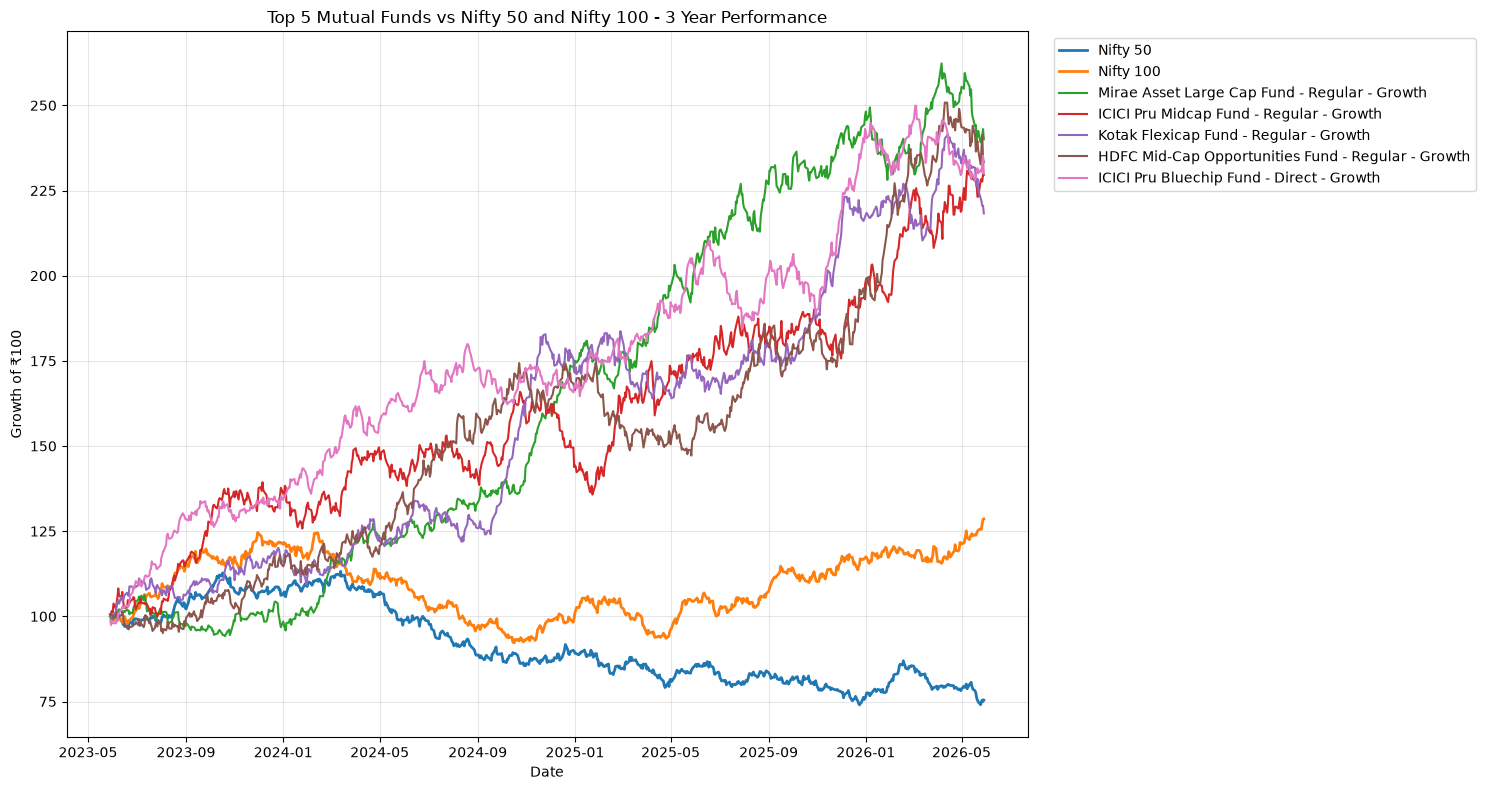

benchmark_comparison.png created successfully


In [89]:
# ============================================
# 11.5 TOP 5 FUNDS VS NIFTY 50 & NIFTY 100
# ============================================

import matplotlib.pyplot as plt

# Benchmark data
benchmark_plot = benchmark_pivot[
    (benchmark_pivot["date"] >= start_date) &
    (benchmark_pivot["date"] <= end_date)
].copy()

# Start with benchmark cumulative values
plot_data = benchmark_plot[
    ["date", "NIFTY50", "NIFTY100"]
].copy()

plot_data["NIFTY50"] = (
    (1 + plot_data["NIFTY50"].fillna(0)).cumprod() * 100
)

plot_data["NIFTY100"] = (
    (1 + plot_data["NIFTY100"].fillna(0)).cumprod() * 100
)

# Add top 5 funds
for code in top5_codes:

    fund_data = fund_returns[
        fund_returns["amfi_code"] == code
    ][
        ["date", "fund_return"]
    ].copy()

    fund_name = top5_funds.loc[
        top5_funds["amfi_code"] == code,
        "scheme_name"
    ].iloc[0]

    fund_data["fund_index"] = (
        (1 + fund_data["fund_return"].fillna(0)).cumprod() * 100
    )

    fund_data = fund_data[
        ["date", "fund_index"]
    ].rename(
        columns={"fund_index": fund_name}
    )

    plot_data = plot_data.merge(
        fund_data,
        on="date",
        how="left"
    )


# ============================================
# PLOT
# ============================================

plt.figure(figsize=(15, 8))

plt.plot(
    plot_data["date"],
    plot_data["NIFTY50"],
    label="Nifty 50",
    linewidth=2
)

plt.plot(
    plot_data["date"],
    plot_data["NIFTY100"],
    label="Nifty 100",
    linewidth=2
)

for code in top5_codes:

    fund_name = top5_funds.loc[
        top5_funds["amfi_code"] == code,
        "scheme_name"
    ].iloc[0]

    plt.plot(
        plot_data["date"],
        plot_data[fund_name],
        label=fund_name
    )

plt.title(
    "Top 5 Mutual Funds vs Nifty 50 and Nifty 100 - 3 Year Performance"
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹100")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save required PNG
plt.savefig(
    "reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("benchmark_comparison.png created successfully")

In [88]:
import os

# Create reports folder if it doesn't exist
os.makedirs("reports", exist_ok=True)

# Save the benchmark comparison chart
plt.savefig(
    "reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("benchmark_comparison.png created successfully")

<Figure size 640x480 with 0 Axes>

benchmark_comparison.png created successfully


In [90]:
tracking_error.to_csv(
    "reports/tracking_error.csv",
    index=False
)

print("tracking_error.csv created successfully")

tracking_error.csv created successfully


In [91]:
import os

os.makedirs("reports", exist_ok=True)

tracking_error.to_csv(
    "reports/tracking_error.csv",
    index=False
)

print("tracking_error.csv created successfully")

tracking_error.csv created successfully
